In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/predict-housing-price-2/estate_train.csv
/kaggle/input/competitions/predict-housing-price-2/estate_sample_submission.csv
/kaggle/input/competitions/predict-housing-price-2/estate_test.csv


In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold

from sklearn.impute import SimpleImputer

from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from xgboost import XGBRegressor

In [3]:
train = pd.read_csv("/kaggle/input/competitions/predict-housing-price-2/estate_train.csv")
test = pd.read_csv("/kaggle/input/competitions/predict-housing-price-2/estate_test.csv")

print(train.shape)
print(test.shape)

train.head()

(16512, 12)
(4128, 11)


,IncomeLevel,PropertyAge,TotalRooms,TotalBedrooms,NeighborhoodPop,AvgOccupancy,Latitude,Longitude,TargetPrice,PropertyID,RoomsPerHousehold,BedroomsRatio
0,3.287977,32.970198,5.128150,0.990769,2339.474039,3.739113,32.71,-117.03,1.030,PROP_14196,1.359130,0.200576
1,3.804601,49.030192,4.372696,1.040469,1269.383596,1.429576,33.77,-118.16,3.821,PROP_08267,2.573820,0.232703
2,4.193302,NaN,5.718626,0.989809,865.436104,2.481219,34.66,-120.48,1.726,PROP_17445,2.073224,0.174486
3,2.029509,36.255617,4.131418,1.032285,1455.381923,3.914447,32.69,-117.11,0.934,PROP_14265,1.002116,0.258269
4,3.540823,42.918534,6.270531,1.147146,895.050628,2.681969,36.78,-119.80,0.965,PROP_02271,2.725400,0.180940


In [4]:
train.info()

train.describe()

train.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16512 entries, 0 to 16511
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   IncomeLevel        16512 non-null  float64
 1   PropertyAge        15199 non-null  float64
 2   TotalRooms         16512 non-null  float64
 3   TotalBedrooms      16512 non-null  float64
 4   NeighborhoodPop    16512 non-null  float64
 5   AvgOccupancy       16512 non-null  float64
 6   Latitude           16512 non-null  float64
 7   Longitude          16512 non-null  float64
 8   TargetPrice        16512 non-null  float64
 9   PropertyID         16512 non-null  object 
 10  RoomsPerHousehold  16512 non-null  float64
 11  BedroomsRatio      16512 non-null  float64
dtypes: float64(11), object(1)
memory usage: 1.5+ MB


IncomeLevel             0
PropertyAge          1313
TotalRooms              0
TotalBedrooms           0
NeighborhoodPop         0
AvgOccupancy            0
Latitude                0
Longitude               0
TargetPrice             0
PropertyID              0
RoomsPerHousehold       0
BedroomsRatio           0
dtype: int64

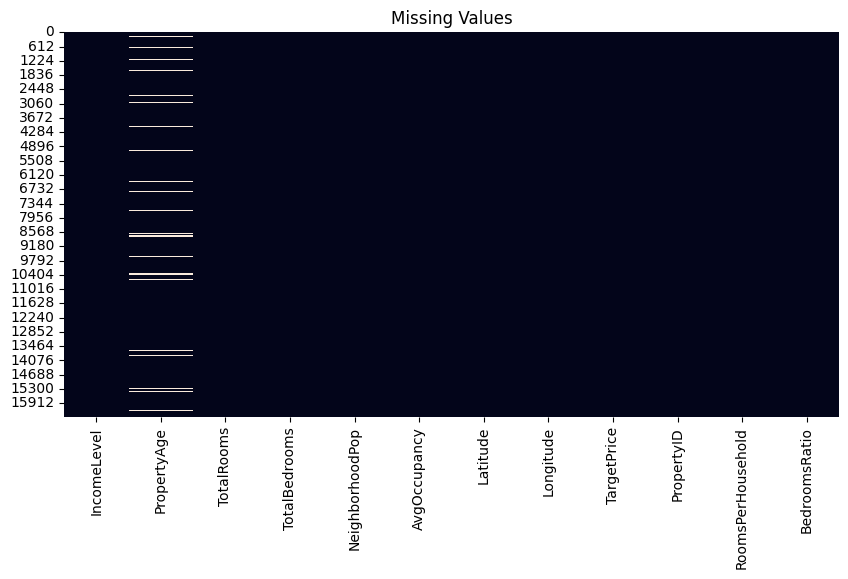

In [5]:
plt.figure(figsize=(10,5))
sns.heatmap(train.isnull(),cbar=False)
plt.title("Missing Values")
plt.show()

In [6]:
median_age = train["PropertyAge"].median()

train["PropertyAge"].fillna(median_age,inplace=True)
test["PropertyAge"].fillna(median_age,inplace=True)

/tmp/ipykernel_16/2778951693.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train["PropertyAge"].fillna(median_age,inplace=True)
/tmp/ipykernel_16/2778951693.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

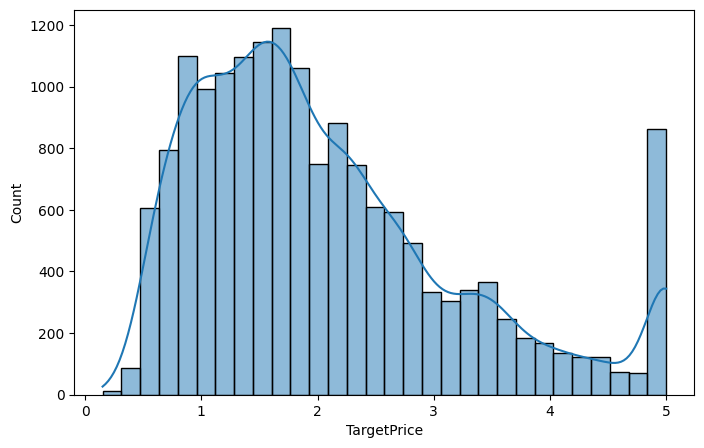

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(train["TargetPrice"],bins=30,kde=True)
plt.show()

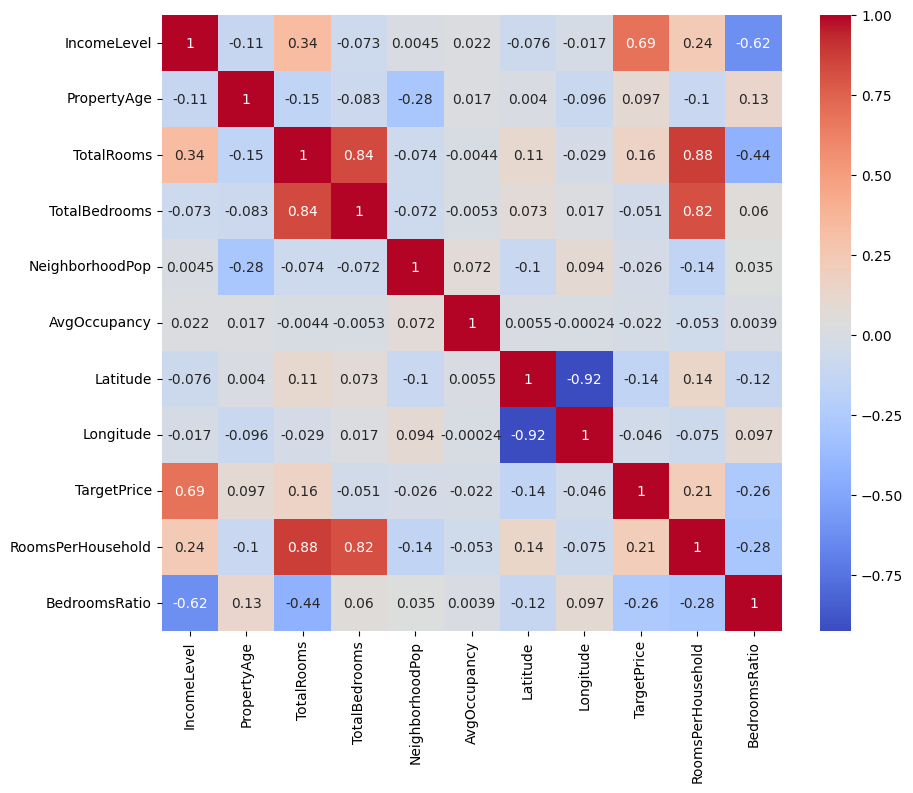

In [8]:
plt.figure(figsize=(10,8))
sns.heatmap(train.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")
plt.show()

<Axes: xlabel='IncomeLevel', ylabel='TargetPrice'>

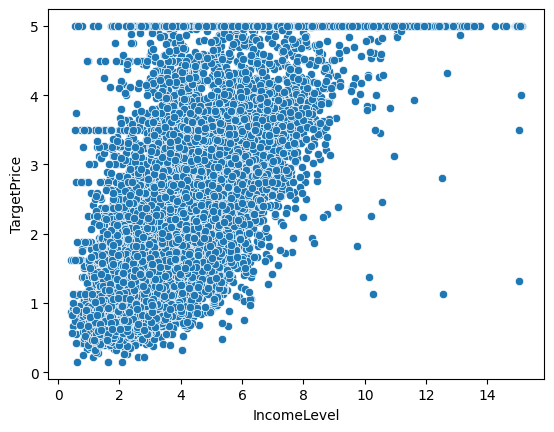

In [9]:
sns.scatterplot(
    x=train["IncomeLevel"],
    y=train["TargetPrice"]
)

In [10]:
for df in [train,test]:

    df["RoomsPerPerson"] = df["TotalRooms"] / (df["NeighborhoodPop"]+1)

    df["BedroomsPerPerson"] = df["TotalBedrooms"] / (df["NeighborhoodPop"]+1)

    df["IncomePerRoom"] = df["IncomeLevel"] / (df["TotalRooms"]+1)

In [11]:
X = train.drop(["PropertyID","TargetPrice"],axis=1)

y = train["TargetPrice"]

X_test = test.drop("PropertyID",axis=1)

In [12]:
X_train,X_valid,y_train,y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
rf = RandomForestRegressor(
    random_state=42
)

rf.fit(X_train,y_train)

pred = rf.predict(X_valid)

rmse = np.sqrt(mean_squared_error(y_valid,pred))

print(rmse)

0.5223909636112894


In [14]:
gb = GradientBoostingRegressor(
    random_state=42
)

gb.fit(X_train,y_train)

pred = gb.predict(X_valid)

rmse = np.sqrt(mean_squared_error(y_valid,pred))

print(rmse)

0.5520492213802473


In [15]:
xgb = XGBRegressor(
    random_state=42,
    objective="reg:squarederror"
)

xgb.fit(X_train,y_train)

pred = xgb.predict(X_valid)

rmse = np.sqrt(mean_squared_error(y_valid,pred))

print(rmse)

0.5028465018522582


In [16]:
models = {
    "Random Forest":rf,
    "Gradient Boosting":gb,
    "XGBoost":xgb
}

for name,model in models.items():

    score = np.sqrt(
        -cross_val_score(
            model,
            X,
            y,
            cv=5,
            scoring="neg_mean_squared_error"
        ).mean()
    )

    print(name,score)

Random Forest 0.5129033465767109
Gradient Boosting 0.5446334506737966
XGBoost 0.4816127834275887


In [17]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

# Base Model
xgb_model = XGBRegressor(
    objective='reg:squarederror',
    random_state=42
)

# Parameter Grid
param_dist = {
    'n_estimators': [200, 300, 500, 800],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.3]
}

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=25,
    scoring='neg_root_mean_squared_error',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV RMSE:")
print(-random_search.best_score_)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best Parameters:
{'subsample': 0.7, 'n_estimators': 800, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.9}

Best CV RMSE:
0.4649001463984484


In [18]:
# Best model from RandomizedSearchCV
best_model = random_search.best_estimator_

# Train on training data
best_model.fit(X_train, y_train)

# Predict validation data
y_pred = best_model.predict(X_valid)

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_valid, y_pred))

print(f"Validation RMSE : {rmse:.4f}")

Validation RMSE : 0.4753


In [19]:
predictions = best_model.predict(X_test)
predictions

array([0.46819258, 0.98669505, 5.4736342 , ..., 4.855776  , 0.6294327 ,
       1.7939305 ], shape=(4128,), dtype=float32)

In [20]:
submission = pd.DataFrame({
    "PropertyID": test["PropertyID"],
    "TargetPrice": predictions
})

submission.to_csv("submission.csv", index=False)

print("submission.csv created successfully.")

submission.csv created successfully.
